# Step 1 · From HPLC chromatograms to an EnzymeML document

Raw Shimadzu exports → the Neu5Ac peak in every chromatogram → calibration with five standards
→ Neu5Ac time courses of 24 reactions → one EnzymeML document.

**Your decisions in this step:** where Neu5Ac elutes (the retention-time window) and whether
the calibration is good enough.

In [1]:
# Setup. In Colab this installs the tools and downloads the workshop; locally it does nothing.
import os
import subprocess
import sys
from pathlib import Path

if "google.colab" in sys.modules and not Path("enzymeml-workshop-modelling-2026").exists():
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "chromhandler==0.10.11", "catalax==0.5.5"], check=True)
    subprocess.run(["git", "clone", "-q", "https://github.com/haeussma/enzymeml-workshop-modelling-2026", "enzymeml-workshop-modelling-2026"], check=True)
if Path("enzymeml-workshop-modelling-2026").exists():
    os.chdir("enzymeml-workshop-modelling-2026")

ROOT = Path.cwd() if (Path.cwd() / "data").exists() else Path.cwd().parent
DATA = ROOT / "data"
CHECKPOINTS = ROOT / "checkpoints"
CHECKPOINTS.mkdir(exist_ok=True)

In [2]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from chromhandler import Handler, to_enzymeml

warnings.filterwarnings("ignore")

PH = 7.5
TEMPERATURE = 37.0  # °C
PUBCHEM_CID = {"ManNAc": 11096158, "PEP": 1005, "Neu5Ac": 439197}

conditions = pd.read_csv(DATA / "conditions.csv").set_index("sample_id")  # initial concentrations in mM
conditions.head()

,ManNAc,PEP,Neu5Ac,NeuS,enzyme
sample_id,,,,,
MAN_M,0.000000,20.0,0,0.000414,0.016
MAN_A,0.039000,20.0,0,0.000414,0.016
MAN_B,0.078125,20.0,0,0.000414,0.016
MAN_C,0.156250,20.0,0,0.000414,0.016
MAN_D,1.250000,20.0,0,0.000414,0.016


## 1 · Read the chromatograms

Each kinetic sample is a folder with six exports named `<sample>_<minutes>min.txt`; the reaction
time is read from the file name. The five calibration standards contain 1 … 5 mM Neu5Ac.

In [3]:
def read_kinetic_sample(folder):
    return Handler.read_shimadzu(folder, ph=PH, temperature=TEMPERATURE, mode="timecourse", silent=True)


sample_folders = sorted(folder for folder in (DATA / "kinetic_series").iterdir() if folder.is_dir())
samples = {folder.name: read_kinetic_sample(folder) for folder in sample_folders}

standard_ids = ["CAL_1", "CAL_2", "CAL_3", "CAL_4", "CAL_5"]
standard_concentrations = conditions.loc[standard_ids, "Neu5Ac"].tolist()
standards = Handler.read_shimadzu(DATA / "calibration", ph=PH, temperature=TEMPERATURE, mode="calibration",
                                  values=standard_concentrations, unit="mmol/l", silent=True)

print(f"{len(samples)} kinetic samples, {len(standards.measurements)} calibration standards")

24 kinetic samples, 5 calibration standards


## 2 · Where does Neu5Ac elute?

Every export comes with a peak table. Plotting all peaks against their retention time shows
where Neu5Ac elutes: near 11.4 min in the calibration standards and near 10.05 min in the
kinetic samples, which were measured in a later session (see `data/README.md`).
The windows below are the scientist's decision: check them against the plot.

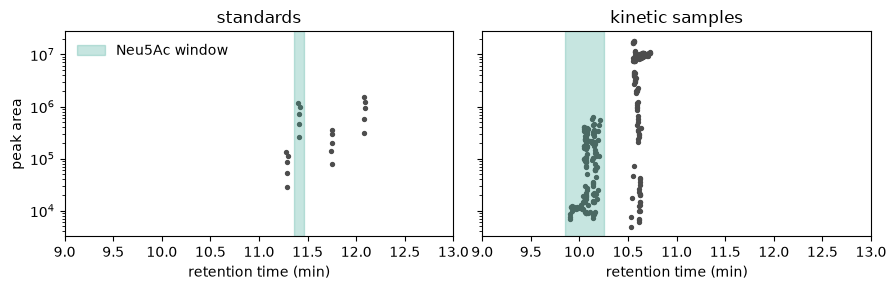

In [4]:
NEU5AC_WINDOW = {  # retention time and tolerance in minutes
    "standards": (11.41, 0.05),
    "kinetic samples": (10.05, 0.20),
}


def peak_table(handler):
    rows = [dict(file=measurement.id, retention_time=peak.retention_time, area=peak.area)
            for measurement in handler.measurements
            for chromatogram in measurement.chromatograms
            for peak in chromatogram.peaks]
    return pd.DataFrame(rows)


peaks = {
    "standards": peak_table(standards),
    "kinetic samples": pd.concat(peak_table(handler) for handler in samples.values()),
}

fig, axes = plt.subplots(1, 2, figsize=(9, 3), sharey=True)
for ax, (label, table) in zip(axes, peaks.items()):
    retention_time, tolerance = NEU5AC_WINDOW[label]
    ax.scatter(table.retention_time, table.area, s=8, color="0.3")
    ax.axvspan(retention_time - tolerance, retention_time + tolerance, color="#44AA99", alpha=0.3, label="Neu5Ac window")
    ax.set(title=label, xlabel="retention time (min)", xlim=(9, 13), yscale="log")
axes[0].set_ylabel("peak area")
axes[0].legend(frameon=False)
plt.tight_layout()

## 3 · Calibrate Neu5Ac

`define_molecule` assigns the one peak inside the window in every standard; `add_standard`
fits peak area against concentration with a line through the origin.

🎯 Assigned Neu5Ac to 5 peaks

✅ Models have been successfully fitted.


                                        Model Overview                                         
┏━━━━━━━━━━━━┳━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Model Name ┃ AIC ┃ R squared ┃ RMSD       ┃ Equation   ┃ Relative Parameter Standard Errors ┃
┡━━━━━━━━━━━━╇━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ linear     │ 94  │ 0.9991    │ 10289.7351 │ Neu5Ac * a │ a: 0.6%,                           │
└────────────┴─────┴───────────┴────────────┴────────────┴────────────────────────────────────┘

Neu5Ac calibration: 239,349 area per mM, R² = 0.9991


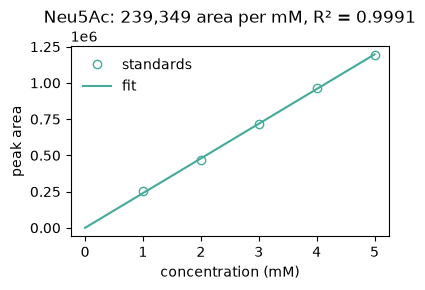

In [5]:
retention_time, tolerance = NEU5AC_WINDOW["standards"]
neu5ac = standards.define_molecule(id="Neu5Ac", pubchem_cid=PUBCHEM_CID["Neu5Ac"], name="Neu5Ac",
                                   retention_time=retention_time, retention_tolerance=tolerance, auto_assign=True)
standards.add_standard(neu5ac, visualize=False)


def assigned_area(measurement, molecule_id):
    """Area of the peak assigned to a molecule in a measurement with one chromatogram."""
    return next(peak.area for peak in measurement.chromatograms[0].peaks if peak.molecule_id == molecule_id)


areas = np.array([assigned_area(measurement, "Neu5Ac") for measurement in standards.measurements])
concentrations = np.array(standard_concentrations)
slope = neu5ac.standard.result.parameters[0].value
r_squared = 1 - np.sum((areas - slope * concentrations) ** 2) / np.sum((areas - areas.mean()) ** 2)
print(f"Neu5Ac calibration: {slope:,.0f} area per mM, R² = {r_squared:.4f}")

plt.figure(figsize=(4, 3))
plt.plot(concentrations, areas, "o", mfc="white", color="#44AA99", label="standards")
plt.plot([0, concentrations.max()], [0, slope * concentrations.max()], "-", color="#44AA99", label="fit")
plt.title(f"Neu5Ac: {slope:,.0f} area per mM, R² = {r_squared:.4f}")
plt.xlabel("concentration (mM)")
plt.ylabel("peak area")
plt.legend(frameon=False)
plt.tight_layout()

assert r_squared > 0.99, f"calibration is poor (R² = {r_squared:.3f})"

## 4 · Concentrations in the kinetic samples, export to EnzymeML

Every kinetic sample receives the calibrated Neu5Ac with the kinetic window, the two substrates
with their initial concentrations (they are not quantified here) and the enzyme. `to_enzymeml`
turns the assigned peak areas into concentrations and writes one document with 24 measurements.

In [6]:
retention_time, tolerance = NEU5AC_WINDOW["kinetic samples"]
for sample_id, handler in samples.items():
    initial = conditions.loc[sample_id]
    product = neu5ac.model_copy(update={"retention_time": retention_time, "retention_tolerance": tolerance})
    handler.add_molecule(product, init_conc=float(initial["Neu5Ac"]), conc_unit="mmol/l",
                         retention_tolerance=tolerance, auto_assign=True)
    for substrate in ("ManNAc", "PEP"):
        handler.define_molecule(id=substrate, pubchem_cid=PUBCHEM_CID[substrate], name=substrate, retention_time=None,
                                init_conc=float(initial[substrate]), conc_unit="mmol/l")
    handler.define_protein(id="NeuS", name="Neu5Ac synthase", init_conc=float(initial["NeuS"]), conc_unit="mmol/l")

document = to_enzymeml("NeuS initial rates", list(samples.values()), calculate_concentration=True, extrapolate=True)
output = CHECKPOINTS / "neus_enzymeml.json"
output.write_text(document.model_dump_json(indent=2))
print(f"{len(document.measurements)} measurements written to {output.relative_to(ROOT)}")

🎯 Assigned Neu5Ac to 6 peaks

🎯 Assigned Neu5Ac to 6 peaks

🎯 Assigned Neu5Ac to 6 peaks

🎯 Assigned Neu5Ac to 6 peaks

🎯 Assigned Neu5Ac to 6 peaks

...

🎯 Assigned Neu5Ac to 6 peaks

🎯 Assigned Neu5Ac to 6 peaks

🎯 Assigned Neu5Ac to 6 peaks

🎯 Assigned Neu5Ac to 6 peaks

24 measurements written to checkpoints/neus_enzymeml.json


## 5 · Checks before moving on

In [7]:
def time_course(measurement, species_id):
    """Time points and concentrations of one species in an EnzymeML measurement."""
    species = next(s for s in measurement.species_data if s.species_id == species_id)
    return np.array(species.time, float), np.array(species.data, float)


assert len(document.measurements) == 24, "expected 24 reactions"
for measurement in document.measurements:
    time, neu5ac_conc = time_course(measurement, "Neu5Ac")
    assert len(time) == 6 and np.all(np.diff(time) > 0), f"{measurement.id}: time points missing or not increasing"
    initial = conditions.loc[measurement.id]
    if initial.ManNAc >= 1 and initial.PEP >= 1:  # controls and µM substrate samples barely react
        assert neu5ac_conc[-1] - neu5ac_conc[0] > 0.2, f"{measurement.id}: less than 0.2 mM Neu5Ac formed"
print("all checks passed")

all checks passed


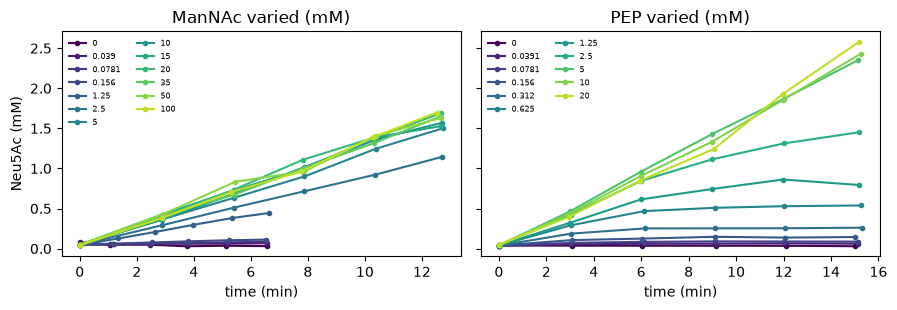

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.2), sharey=True)
for ax, prefix, varied in [(axes[0], "MAN_", "ManNAc"), (axes[1], "PEP_", "PEP")]:
    series = sorted((m for m in document.measurements if m.id.startswith(prefix)), key=lambda m: conditions.loc[m.id, varied])
    colors = plt.cm.viridis(np.linspace(0, 0.9, len(series)))
    for color, measurement in zip(colors, series):
        time, neu5ac_conc = time_course(measurement, "Neu5Ac")
        ax.plot(time, neu5ac_conc, "o-", ms=3, color=color, label=f"{conditions.loc[measurement.id, varied]:.3g}")
    ax.set(title=f"{varied} varied (mM)", xlabel="time (min)")
    ax.legend(fontsize=6, ncol=2, frameon=False)
axes[0].set_ylabel("Neu5Ac (mM)")
plt.tight_layout()